# Глубокое машинное обучение
## HW2: Natural Language Processing

**Задача #2: Восстановление пунктуации и капитализации**

Дата *жесткого* дедлайна: `21.12.2025 23:59`




### **Правила сдачи (обязательно к прочтению)**

- После **жесткого** дедлайна работы не принимаются.
- Все похожие друг на друга работы оцениваются в 0.
- Если вы использовали какой-то публичный код, то это необходимо указать в комментарии и приложить ссылку на источник, иначе тоже может быть 0. :(
- За нечитаемый код, неэффективную реализацию и _некрасивые_ визуализации могут быть сняты баллы.
- Все вычисления должны быть воспроизводимые, поэтому не забывайте про `seed=42`, а также не забудьте перезапустить ноутбук и прожать все ячейки - ошибок быть не должно.
- Готовый ноутбук со всеми данными необходимо положить в архив. В архив необходимо положить ваш requirments.txt со всеми версиями библиотек.
- Архив называется следующим образом: `HW1_<your_latin_name>.zip`. Пример: `HW1_malkov.zip`
- Для всех трейнов важно предоставить графики лосов/эпох. Легче всего оставить ссылку на wandb, если такой возможности нет, то делайте графики сами.
- Использовать LLM можно, но допускается не более 50% сгенерированного кода в каждом задании. В случае использования LLM нужно комментарием указать модель, промт и источник инференса. Если нет комментария или количество сгенерированного кода больше 50%, то за задание ставится 0. Пример:
```python
# LLM START
"""
Model: Qwen3-30B-A3B-FP8 (указать квантизацию и кастомные параметры (top-p, top-p, temperature, ...), если есть)
Source: vLLM (здесь может быть API (openrouter.ai), может быть сайт с чатиком (chat.z.ai), может быть тула для локального инференса (lm-studio), может быть TG-бот (@jadvebot))
Prompt: Мой китайский друг, представь, что ты Ян Ле Кун, придумай за меня алгоритм детекции тачулечек
"""
print("Hello world")
# LLM END
```


### **Правила оценки работы**

Всего за работу можно получить **50** баллов.

Вот как выглядит отображение баллов в оценки:

| [От и До) | Оценка |
|-----------|--------|
| 0-5       | 1      |
| 5-10      | 2      |
| 10-15     | 3      |
| 15-20     | 4      |
| 20-26     | 5      |
| 26-30     | 6      |
| 30-35     | 7      |
| 35-40     | 8      |
| 40-45     | 9      |
| 45-50     | 10     |

**Regular**-задания обязательны для проходной оценки. **Honor** — опционально.


### Предисловие

Современные системы автоматического распознавания речи (ASR) достигли впечатляющей точности в транскрибации слов. Однако сырой выход таких систем часто представляет собой непрерывный поток текста в нижнем регистре без знаков препинания. Такой текст:
- Трудно читаем для человека.
- Значительно снижает качество работы последующих NLP-моделей (машинный перевод, NER, анализ тональности), которые полагаются на границы предложений и именные сущности.

В этой работе мы решаем задачу автоматического восстановления пунктуации и капитализации. На вход модели подается неформатированный текст (эмуляция выхода ASR), а на выходе мы ожидаем текст с расставленными знаками препинания и заглавными буквами.

Мы предполагаем, что синтаксическая и семантическая информация, содержащаяся в контексте предложения, достаточна для восстановления форматирования.
Использование предобученной языковой модели позволит извлекать глубокие контекстуальные эмбеддинги слов, на основе которых можно классифицировать необходимость постановки знака или изменения регистра.


### Архитектура

Для решения задачи мы используем архитектуру с двумя головами классификации на базе трансформера:
* Backbone: Предобученная модель `BERT`. Она принимает последовательность токенов и генерирует контекстуальные векторы для каждого из них.
* Heads: Поверх выходных эмбеддингов `BERT` навешиваются два независимых линейных классификатора:
    - Head 1: Предсказывает знак препинания, который должен стоять после текущего токена.  Классы: `O` (нет знака), `,`, `.`, `?`, `!` и др.

    - Head 2: Предсказывает регистр текущего токена. Классы: `L` (строчная), `U` (заглавная).

Обучение происходит в режиме Joint Learning. Мы минимизируем суммарную функцию потерь, что позволяет модели выучивать зависимости между интонационными паузами и началом предложений/именами собственными:

$$Loss_{total} = Loss_{punct} + Loss_{cap}$$

Где $Loss_{punct}\ $ и $Loss_{cap}\ $ — стандартные `CrossEntropyLoss` для соответствующих задач.

### Метрики качества

В данной задаче наблюдается сильный дисбаланс классов:

- Большинство слов не требуют знака препинания (класс O доминирует).
- Большинство слов пишутся со строчной буквы (класс L доминирует).

Для корректной оценки мы используем следующий набор метрик:

* Для пунктуации:
    - F1-score (micro/macro): Рассчитывается исключая мажоритарный класс O. Это позволяет оценить, насколько хорошо модель находит именно значимые знаки препинания, игнорируя пустые места.
* Для капитализации:
    - Accuracy: Общая точность (считается только по валидным токенам, игнорируя паддинги/спецтокены).
    - F1-score (Upper): Целевая метрика для класса "Заглавная буква" (U). Она показывает способность модели детектировать начала предложений и именованные сущности.

### 0. Импорт всего, что нужно, и определение констант

In [65]:
# Если вы запускаете на чистом окружении (не в google colab / kaggle) — раскомментируйте установки.
# !pip -q install -U transformers datasets accelerate evaluate scikit-learn matplotlib tqdm

import os
import re
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, AutoConfig

from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("DEVICE:", DEVICE)


DEVICE: cuda


In [66]:
# Примечание: Множество пунктуации можно расширять.
# По умолчанию используются O / , / . / ?  (и отдельно капитализацию U/O).

PUNCT_LABELS = ["O", ",", ".", "?", "!"]  # знак СЛЕДУЕТ ПОСЛЕ слова
CAP_LABELS = ["O", "U"]  # O = оставить lower, U = сделать TitleCase (первая буква заглавная)

punct2id = {p: i for i, p in enumerate(PUNCT_LABELS)}
id2punct = {i: p for p, i in punct2id.items()}

cap2id = {c: i for i, c in enumerate(CAP_LABELS)}
id2cap = {i: c for c, i in cap2id.items()}

print("PUNCT_LABELS:", PUNCT_LABELS)
print("CAP_LABELS:", CAP_LABELS)


PUNCT_LABELS: ['O', ',', '.', '?', '!']
CAP_LABELS: ['O', 'U']


### (reg, 5.0) 1. Датасет и преобразование к целевой разметке

**Что нужно сделать:**
1) Взять любой текстовый датасет.
2) Преобразовать тексты так, чтобы у каждого слова был:
   - `punct_label`: какой знак пунктуации **после** слова
   - `cap_label`: нужно ли слово писать с заглавной
3) Подготовить train/val/test.


#### (reg, 1.0) 1.1 Загружаем сырой текстовый датасет

Вы можете взять любой текстовый датасет. Рекомендуем вам посмотреть различные варианты на `huggingface`

Я взяла датасет с kaggle https://www.kaggle.com/datasets/hetpatel01/movie-genres-overview, в качестве выборки буду использовать тексты с описанием фильмов оттуда.

In [67]:
import pandas as pd

In [68]:
df = pd.read_csv("wiki_movie_plots_deduped.csv")
df = df["Plot"]
df.head()

,Plot
0,"A bartender is working at a saloon, serving dr..."
1,"The moon, painted with a smiling face hangs ov..."
2,"The film, just over a minute long, is composed..."
3,Lasting just 61 seconds and consisting of two ...
4,The earliest known adaptation of the classic f...


#### (reg, 3.0) 1.2 Конвертация сырого текста в (слова, метки)

Нужно получить для каждого предложения:
- `words`: список слов
- `punct_labels`: список меток пунктуации длины `len(words)`
- `cap_labels`: список меток капитализации длины `len(words)`

Правила разметки:
- Пунктуацию учитываем **только** из множества `PUNCT_LABELS` (остальную можно игнорировать/удалять).
- Метка пунктуации относится к **предыдущему слову** (знак идёт **после** слова).
- Капитализация — бинарная: `U`, если слово в оригинале начиналось с заглавной буквы, иначе `O`.

ПРИМЕР:


```python
ex = "When is the next flight to New York? Great, how about you!"
sentence_to_words_and_labels(ex)
```

Output:

```
(['When',
  'is',
  'the',
  'next',
  'flight',
  'to',
  'New',
  'York',
  'Great',
  'how',
  'about',
  'you'],
 ['O', 'O', 'O', 'O', 'O', 'O', 'O', '?', ',', 'O', 'O', 'O'],
 ['U', 'O', 'O', 'O', 'O', 'O', 'U', 'U', 'U', 'O', 'O', 'O'])
```

> Примечание: Данный вывод получается, если: `
PUNCT_LABELS = ["O", ",", ".", "?"]; CAP_LABELS = ["O", "U"]`




In [69]:
import re

def sentence_to_words_and_labels(text):
    word_re = re.compile(r"[\w]+(?:[-'][\w]+)*", flags=re.UNICODE)
    token_re = re.compile(rf"{word_re.pattern}|[^\s]", flags=re.UNICODE)

    words = []
    punct = []
    cap = []

    last_word_idx = -1

    for m in token_re.finditer(text):
        tok = m.group(0)

        if word_re.fullmatch(tok):
            words.append(tok.lower())
            punct.append("O")
            cap.append("U" if tok[:1].isupper() else "O")
            last_word_idx += 1
        else:
            if tok in PUNCT_LABELS and tok != "O" and last_word_idx >= 0:
                if punct[last_word_idx] == "O":
                    punct[last_word_idx] = tok

    return words, punct, cap


ex = "When is the next flight to New York? Great, how about you!"
print(sentence_to_words_and_labels(ex))


(['when', 'is', 'the', 'next', 'flight', 'to', 'new', 'york', 'great', 'how', 'about', 'you'], ['O', 'O', 'O', 'O', 'O', 'O', 'O', '?', ',', 'O', 'O', '!'], ['U', 'O', 'O', 'O', 'O', 'O', 'U', 'U', 'U', 'O', 'O', 'O'])


#### (reg, 1.0) 1.3 Сбор датасета и разбиение на train/val/test

Сконвертируйте датасет в список примеров и сделайте сплиты.

> Примечание: Если хотите увидеть реальное качественное решение, используйте больше данных

Ваши train/val/test датасеты должны выглядеть примерно так:

```
Dataset({
     features: ['words', 'punct', 'cap'],
     num_rows: XXX
 })
```


In [70]:
samples = []

for i in range(len(df)):
  words, punct, cap = sentence_to_words_and_labels(df[i])
  samples.append({
            "words": words,
            "punct": [punct2id[p] for p in punct],
            "cap": [cap2id[c] for c in cap],
        })

In [71]:
print(len(samples))
print(samples[0])

34886
{'words': ['a', 'bartender', 'is', 'working', 'at', 'a', 'saloon', 'serving', 'drinks', 'to', 'customers', 'after', 'he', 'fills', 'a', 'stereotypically', 'irish', "man's", 'bucket', 'with', 'beer', 'carrie', 'nation', 'and', 'her', 'followers', 'burst', 'inside', 'they', 'assault', 'the', 'irish', 'man', 'pulling', 'his', 'hat', 'over', 'his', 'eyes', 'and', 'then', 'dumping', 'the', 'beer', 'over', 'his', 'head', 'the', 'group', 'then', 'begin', 'wrecking', 'the', 'bar', 'smashing', 'the', 'fixtures', 'mirrors', 'and', 'breaking', 'the', 'cash', 'register', 'the', 'bartender', 'then', 'sprays', 'seltzer', 'water', 'in', "nation's", 'face', 'before', 'a', 'group', 'of', 'policemen', 'appear', 'and', 'order', 'everybody', 'to', 'leave', '1'], 'punct': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [72]:
from datasets import Dataset, DatasetDict


ds = Dataset.from_list(samples)

train_rest = ds.train_test_split(test_size=0.2, seed=42)
train = train_rest["train"]
rest = train_rest["test"]
val_test = rest.train_test_split(test_size=0.5, seed=42)
val = val_test["train"]
test = val_test["test"]

dataset = DatasetDict({"train": train, "val": val, "test": test})
print(dataset)
print(dataset["train"])


DatasetDict({
    train: Dataset({
        features: ['words', 'punct', 'cap'],
        num_rows: 27908
    })
    val: Dataset({
        features: ['words', 'punct', 'cap'],
        num_rows: 3489
    })
    test: Dataset({
        features: ['words', 'punct', 'cap'],
        num_rows: 3489
    })
})
Dataset({
    features: ['words', 'punct', 'cap'],
    num_rows: 27908
})


### (reg, 5.0) 2. Токенизация и выравнивание меток по subword-ам

BERT использует subword-токены, а разметка у нас на уровне **слов**. Нужно:

- токенизировать `words` с параметром `is_split_into_words=True`
- разнести метки по токенам так, чтобы **только первый subword** слова получал label, остальные — `-100` (ignore)

Это стандартный подход для token classification.


#### (reg, 3.0) 2.1 Реализуйте выравнивание меток и класс Dataset

ПРИМЕР:

```python
print(train_dataset_aligned[0])
```

Output:

```python
{'input_ids': [101, 10182, 40796, ..., 10182, 31, 100],
 'attention_mask': [1, 1, 1,  ..., 1, 1, 1],
 'labels_punct': [-100, 0,  , ..., 0, 0, -100],
 'labels_cap': [-100, 1, 1, ..., 1, 1, -100]}
```

In [73]:
def align_labels_for_token_classification(
    tokenizer,
    words,
    punct_word_ids,
    cap_word_ids,
    max_length = None,
):

    encoded = tokenizer(
        words,
        is_split_into_words=True,
        add_special_tokens=True,
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
    )

    word_ids = encoded.word_ids()

    labels_punct = []
    labels_cap = []

    prev_word_id = None
    for word_id in word_ids:
        if word_id is None:
            labels_punct.append(-100)
            labels_cap.append(-100)
            prev_word_id = None
            continue

        first_subword = (word_id != prev_word_id)
        if first_subword:
            labels_punct.append(int(punct_word_ids[word_id]))
            labels_cap.append(int(cap_word_ids[word_id]))
        else:
            labels_punct.append(-100)
            labels_cap.append(-100)

        prev_word_id = word_id

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "labels_punct": labels_punct,
        "labels_cap": labels_cap,
    }

In [74]:
from torch.utils.data import Dataset as torch_dataset

class AlignedTokenDataset(torch_dataset):
    def __init__(
        self,
        samples,
        tokenizer,
        max_length = None,
    ):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if isinstance(idx, (list, tuple, np.ndarray)):
            batch_list = []
            for i in idx:
                ex = self.samples[i]

                try:
                    batch_list.append(align_labels_for_token_classification(
                        self.tokenizer, ex["words"], ex["punct"], ex["cap"], self.max_length
                    ))
                except Exception as e:
                    print("Ошибка на индексе:", i)
            return batch_list
        else:
            ex = self.samples[idx]
            return align_labels_for_token_classification(
                self.tokenizer, ex["words"], ex["punct"], ex["cap"], self.max_length)

#### (reg, 2.0) 2.2 Реализуйте collate_fn с паддингом

Нужно паддить `input_ids`, `attention_mask`, а также две матрицы меток (паддинг меток = `-100`).

ПРИМЕР:

```python
next(iter(train_loader)).keys()
```

Output:
```
{'input_ids': [
        [   101,  11170,  88195,  ...,      0,      0,      0],
        [   101,  10182,  40796,  ...,  10182,     31,    100],
        ...,
        [   101,  20933, 110712,  ...,      0,      0,      0]],
 'attention_mask': [
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0]],
 'labels_punct': [
        [-100,    0, -100,  ..., -100, -100, -100],
        [-100,    0,    0,  ...,    0,    0, -100],
        ...,
        [-100,    0, -100,  ..., -100, -100, -100]],
 'labels_cap': [
        [-100,    1, -100,  ..., -100, -100, -100],
        [-100,    1,    1,  ...,    1,     1, -100],
        ...,
        [-100,    1, -100,  ..., -100, -100, -100]]}
```

In [75]:
@dataclass
class Collator:
    tokenizer: AutoTokenizer
    label_pad_id = -100

    def __call__(self, batch):
        pad_id = self.tokenizer.pad_token_id

        max_len = max(len(x["input_ids"]) for x in batch)

        input_ids = []
        attention_mask = []
        labels_punct = []
        labels_cap = []

        for item in batch:
            cur_len = len(item["input_ids"])
            need_pad = max_len - cur_len

            input_ids.append(item["input_ids"] + [pad_id] * need_pad)
            attention_mask.append(item["attention_mask"] + [0] * need_pad)
            labels_punct.append(item["labels_punct"] + [self.label_pad_id] * need_pad)
            labels_cap.append(item["labels_cap"] + [self.label_pad_id] * need_pad)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels_punct": torch.tensor(labels_punct, dtype=torch.long),
            "labels_cap": torch.tensor(labels_cap, dtype=torch.long),
        }

In [85]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

train_dataset_aligned = AlignedTokenDataset(dataset['train'], tokenizer, max_length=128)
val_dataset_aligned   = AlignedTokenDataset(dataset['val'], tokenizer, max_length=128)
test_dataset_aligned  = AlignedTokenDataset(dataset['test'], tokenizer, max_length=128)

collate_fn = Collator(tokenizer)

train_loader = DataLoader(train_dataset_aligned, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True, persistent_workers=True)
batch = next(iter(train_loader))
print(train_dataset_aligned[0])
print(batch.keys())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


{'input_ids': [101, 1505, 9858, 1671, 189, 1183, 18201, 181, 19009, 193, 8734, 100, 100, 1307, 1118, 10552, 1403, 22572, 9513, 18908, 1103, 2448, 176, 19284, 170, 10501, 4837, 1111, 170, 2343, 1231, 17405, 1933, 1105, 2745, 1488, 1813, 2815, 1106, 1243, 9297, 1104, 1103, 2343, 1297, 1107, 1103, 1298, 3655, 1106, 1140, 1103, 2448, 176, 19284, 1110, 1103, 1313, 1104, 1143, 15615, 8209, 7136, 1105, 1103, 1488, 1813, 1107, 1901, 1106, 2302, 11738, 1144, 2416, 1242, 1104, 1172, 1106, 2939, 1137, 1243, 4809, 1103, 1374, 8771, 1686, 1107, 1126, 3928, 2062, 2246, 21486, 1107, 1103, 176, 19284, 1105, 1328, 1106, 15467, 2193, 193, 8734, 1111, 1117, 19301, 1103, 1143, 11931, 4063, 1377, 3952, 188, 3822, 100, 1307, 1118, 181, 1394, 194, 3488, 170, 2712, 1685, 1143, 24744, 1150, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

### (reg, 5.0) 3. Модель: BERT + две головы классификации

Нужно реализовать модель:
- backbone: `AutoModel.from_pretrained(YOUR_MODEL_NAME)`
- голова 1: `punct_head` (len(PUNCT_LABELS) классов)
- голова 2: `cap_head` (len(CAP_LABELS) классов)
- loss = `loss_punct + loss_cap` с `ignore_index=-100`.


#### (reg, 4.0) 3.1 Реализуйте класс модели и forward

In [77]:
class BertTwoHeads(nn.Module):
    def __init__(self, model_name, num_punct, num_cap, dropout=0.1):
        super().__init__()

        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name, config=self.config)

        h = self.config.hidden_size
        self.drop = nn.Dropout(dropout)

        self.punct_head = nn.Linear(h, num_punct)
        self.cap_head   = nn.Linear(h, num_cap)

        self.ignore_index = -100

    def forward(self, input_ids, attention_mask=None, labels_punct=None, labels_cap=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = self.drop(out.last_hidden_state)

        logits_punct = self.punct_head(x)
        logits_cap   = self.cap_head(x)

        res = {
            "logits_punct": logits_punct,
            "logits_cap": logits_cap,
        }

        if labels_punct is not None and labels_cap is not None:
            loss_punct = F.cross_entropy(
                logits_punct.view(-1, logits_punct.size(-1)),
                labels_punct.view(-1),
                ignore_index=self.ignore_index
            )
            loss_cap = F.cross_entropy(
                logits_cap.view(-1, logits_cap.size(-1)),
                labels_cap.view(-1),
                ignore_index=self.ignore_index
            )
            res["loss_punct"] = loss_punct
            res["loss_cap"] = loss_cap
            res["loss"] = loss_punct + loss_cap

        return res


In [78]:
model_name = "bert-base-cased"
model = BertTwoHeads(
    model_name,
    num_punct=len(PUNCT_LABELS),
    num_cap=len(CAP_LABELS),
    dropout=0.1
)

#### (reg, 1.0) 3.2 Подготовьте оптимизатор и scheduler

Используйте AdamW и linear warmup (например 10% шагов).

In [79]:
epochs = 2
lr = 5e-5
weight_decay = 0.01

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

total_steps = len(train_loader) * epochs
warmup_steps = int(total_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("total_steps =", total_steps, "| warmup_steps =", warmup_steps)

total_steps = 3490 | warmup_steps = 349


### (reg, 12.0) 4. Обучение и валидация

Нужно:
- написать train loop
- написать eval loop
- посчитать метрики на val

Метрики (минимум):
- для пунктуации: F1 (micro или macro) **без класса `O`**
- для капитализации: accuracy (по токенам, где label != -100), **а также** F1_upper (Метрика F1, посчитанная для класса "U")


#### (reg, 5.0) 4.1 Реализуйте шаг обучения (train_epoch)

Напишите функцию для шага обучения

> ВНИМАНИЕ! Не забудьте про графики! Прикрепите к решению wandb или постройте графики самостоятельно.

In [80]:
def train_epoch(model, loader, optimizer, scheduler, device, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    n_steps = 0

    pbar = tqdm(loader, desc="Train", leave=True)

    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_punct=batch["labels_punct"],
            labels_cap=batch["labels_cap"],
        )

        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        n_steps += 1

        pbar.set_postfix(loss=loss.item())

    return total_loss / max(1, n_steps)


#### (reg, 5.0) 4.2 Реализуйте оценку и метрики (evaluate)

Напишите функцию, которая собирает предсказания по токенам, фильтрует `-100` и считает метрики.

> ВНИМАНИЕ! Не забудьте про графики! Прикрепите к решению wandb или постройте графики самостоятельно.

In [81]:
def compute_metrics(all_punct_true, all_punct_pred, all_cap_true, all_cap_pred):
    all_punct_true = np.array(all_punct_true)
    all_punct_pred = np.array(all_punct_pred)
    all_cap_true   = np.array(all_cap_true)
    all_cap_pred   = np.array(all_cap_pred)

    o_id = punct2id.get("O")
    u_id = cap2id.get("U")

    mask_noO = (all_punct_true != o_id)
    if mask_noO.sum() == 0:
        punct_f1_micro_noO = 0.0
        punct_f1_macro_noO = 0.0
    else:
        y_true_noO = all_punct_true[mask_noO]
        y_pred_noO = all_punct_pred[mask_noO]

        labels_noO = [i for i in range(len(punct2id)) if i != o_id]

        punct_f1_micro_noO = f1_score(y_true_noO, y_pred_noO, average="micro", labels=labels_noO, zero_division=0)
        punct_f1_macro_noO = f1_score(y_true_noO, y_pred_noO, average="macro", labels=labels_noO, zero_division=0)

    cap_accuracy = (all_cap_true == all_cap_pred).mean() if len(all_cap_true) else 0.0

    cap_f1_upper = f1_score((all_cap_true == u_id).astype(int),
                            (all_cap_pred == u_id).astype(int),
                            average="binary",
                            zero_division=0) if len(all_cap_true) else 0.0

    return {
        "punct_f1_micro_noO": float(punct_f1_micro_noO),
        "punct_f1_macro_noO": float(punct_f1_macro_noO),
        "cap_accuracy": float(cap_accuracy),
        "cap_f1_upper": float(cap_f1_upper),
    }


In [82]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_steps = 0

    all_punct_true, all_punct_pred = [], []
    all_cap_true, all_cap_pred = [], []

    pbar = tqdm(loader, desc="Evaluation", leave=True)

    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_punct=batch["labels_punct"],
            labels_cap=batch["labels_cap"],
        )

        loss = out["loss"]
        total_loss += loss.item()
        n_steps += 1

        punct_pred = out["logits_punct"].argmax(dim=-1)
        cap_pred   = out["logits_cap"].argmax(dim=-1)

        punct_true = batch["labels_punct"]
        cap_true   = batch["labels_cap"]

        mask_p = (punct_true != -100)
        mask_c = (cap_true != -100)

        all_punct_true.extend(punct_true[mask_p].detach().cpu().tolist())
        all_punct_pred.extend(punct_pred[mask_p].detach().cpu().tolist())

        all_cap_true.extend(cap_true[mask_c].detach().cpu().tolist())
        all_cap_pred.extend(cap_pred[mask_c].detach().cpu().tolist())

        pbar.set_postfix(loss=loss.item())

    avg_loss = total_loss / max(1, n_steps)
    metrics = compute_metrics(all_punct_true, all_punct_pred, all_cap_true, all_cap_pred)
    metrics["val_loss"] = float(avg_loss)

    return metrics

#### (reg, 2.0) 4.3 Запустите обучение и покажите динамику

ПРИМЕР ВЫВОДА:

```
Train:      100%|██████████| X/X [02:23<00:00,  5.22it/s]
Evaluation: 100%|██████████| X/X [00:14<00:00,  3.33it/s]
Epoch 01 | train_loss=XXX | val_loss=XXX | punct_f1_micro_noO=XXX | cap_acc=XXX
[{'epoch': 1,
  'train_loss': XXX,
  'loss': XXX,
  'punct_f1_micro_noO': XXX,
  'punct_f1_macro_noO': XXX,
  'cap_accuracy': XXX,
  'cap_f1_upper': XXX}]
```

> ВНИМАНИЕ! Не забудьте про графики! Прикрепите к решению wandb или постройте графики самостоятельно.



In [83]:
def plot_history(history):
    epochs = [h["epoch"] for h in history]

    plt.figure()
    plt.plot(epochs, [h["train_loss"] for h in history], label="train_loss")
    plt.plot(epochs, [h["val_loss"] for h in history], label="val_loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, [h["punct_f1_micro_noO"] for h in history], label="punct_f1_micro_noO")
    plt.plot(epochs, [h["punct_f1_macro_noO"] for h in history], label="punct_f1_macro_noO")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, [h["cap_accuracy"] for h in history], label="cap_accuracy")
    plt.plot(epochs, [h["cap_f1_upper"] for h in history], label="cap_f1_upper")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()


def fit(model, train_loader, val_loader, optimizer, scheduler, device, epochs=3):
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)

        val_metrics = evaluate(model, val_loader, device)

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            **val_metrics
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} | val_loss={row['val_loss']:.4f} | "
            f"punct_f1_micro_noO={row['punct_f1_micro_noO']:.4f} | "
            f"punct_f1_macro_noO={row['punct_f1_macro_noO']:.4f} | "
            f"cap_acc={row['cap_accuracy']:.4f} | cap_f1_upper={row['cap_f1_upper']:.4f}"
        )

    plot_history(history)
    return history


Epoch 01 | train_loss=0.1861 | val_loss=0.1485 | punct_f1_micro_noO=0.8263 | punct_f1_macro_noO=0.5707 | cap_acc=0.9832 | cap_f1_upper=0.9584


Epoch 02 | train_loss=0.1210 | val_loss=0.1430 | punct_f1_micro_noO=0.8731 | punct_f1_macro_noO=0.6499 | cap_acc=0.9844 | cap_f1_upper=0.9616


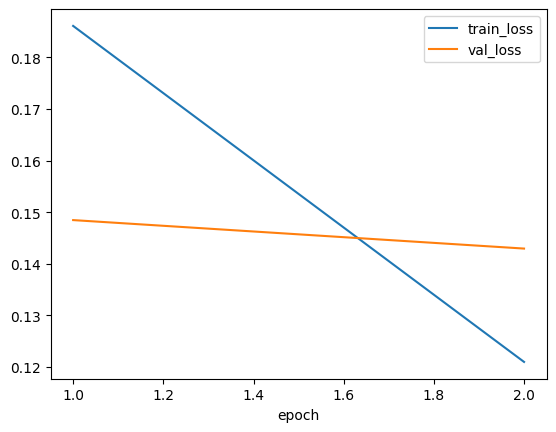

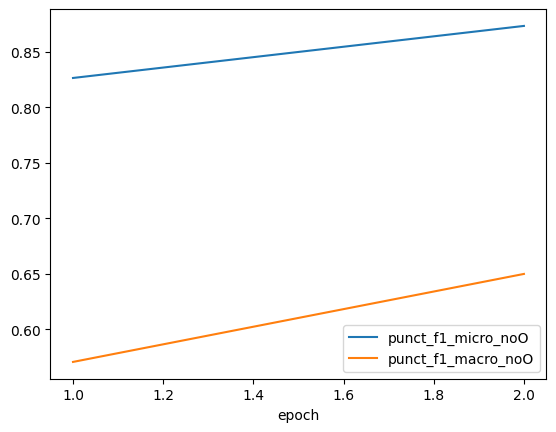

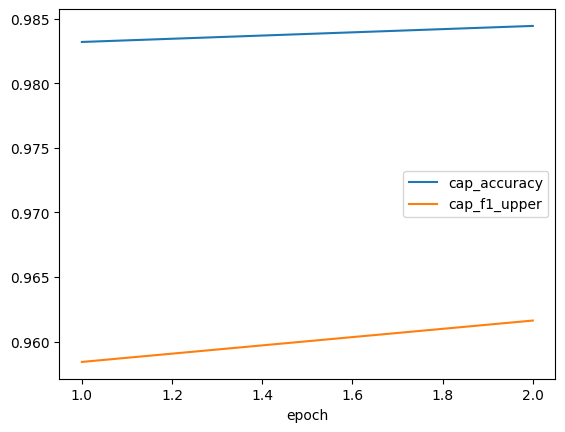

[{'epoch': 1,
  'train_loss': 0.18606548878046708,
  'punct_f1_micro_noO': 0.8262935850189265,
  'punct_f1_macro_noO': 0.5707492095003992,
  'cap_accuracy': 0.9832001326048733,
  'cap_f1_upper': 0.9584328484234397,
  'val_loss': 0.14846729861410785},
 {'epoch': 2,
  'train_loss': 0.12100587001758865,
  'punct_f1_micro_noO': 0.8731328931341753,
  'punct_f1_macro_noO': 0.6499399251054869,
  'cap_accuracy': 0.984441678231675,
  'cap_f1_upper': 0.961634942897215,
  'val_loss': 0.14295413111045224}]

In [86]:
model.to(DEVICE)

val_loader = DataLoader(val_dataset_aligned, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True,
    persistent_workers=True)

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    epochs=epochs
)

history


### (reg, 8.0) 5. Инференс: восстановление пунктуации и капитализации

Нужно написать функцию `restore(text: str) -> str`, которая:
- принимает строку без пунктуации (и, как правило, в lower)
- разбивает на слова по пробелам
- прогоняет модель
- для каждого слова применяет predicted capitalization
- добавляет predicted punctuation после слова

> **Важно**: в инференсе тоже нужна токенизация и выравнивание обратно к словам (берём предсказание первого subword).


#### (reg, 6.0) 5.1 Реализуйте word-level инференс и восстановление строки

ПРИМЕР:

```python
print(restore("we are flying to new york"))
print(restore("how old are you"))
print(restore("this is cool great and awesome"))
```

Output:
```
We are flying to New York.
How old are you?
This is cool, great and awesome.
```

In [87]:
@torch.no_grad()
def restore(text, max_length=128):
    words = text.strip().split()

    encoded = tokenizer(
        words,
        is_split_into_words=True,
        add_special_tokens=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    word_ids = encoded.word_ids(0)

    device = next(model.parameters()).device
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    model.eval()
    output = model(input_ids=input_ids, attention_mask=attention_mask)

    punct_token_preds = output["logits_punct"].argmax(-1)[0].tolist()
    cap_token_preds = output["logits_cap"].argmax(-1)[0].tolist()

    punct_word_preds = [punct2id["O"]] * len(words)
    cap_word_preds = [cap2id["O"]] * len(words)

    prev_word_id = None
    for token_i, word_id in enumerate(word_ids):
        if word_id is None:
            prev_word_id = None
            continue
        if word_id != prev_word_id:
            punct_word_preds[word_id] = punct_token_preds[token_i]
            cap_word_preds[word_id] = cap_token_preds[token_i]
        prev_word_id = word_id

    restored_words = []
    for i, word in enumerate(words):
        cap_label = id2cap[cap_word_preds[i]]
        punct_label = id2punct[punct_word_preds[i]]

        word = word.lower()
        if cap_label == "U":
            word = word[:1].upper() + word[1:]

        if punct_label != "O":
            word = word + punct_label

        restored_words.append(word)

    return " ".join(restored_words)

#### (reg, 2.0) 5.2 Примеры инференса на тестовых строках

Покажите 5-10 примеров: вход → выход модели → (опционально) эталон.

ПРИМЕР ВЫВОДА:

```
IN : this is a test it should look nicer
OUT: This is a test. It should look nicer.

IN : i live in berlin and i like nlp
OUT: I live in Berlin and I like Nlp.

IN : what do you think about bert models
OUT: What do you think about Bert models?

IN : today we train two heads for punctuation and capitalization
OUT: Today we train two heads for punctuation and capitalization.
```

In [ ]:
# YOUR CODE HERE (examples)

In [88]:
tests = [
    "this is a test it should look nicer",
    "i live in berlin and i like nlp",
    "what do you think about bert models",
    "i live in berlin and i like nlp",
    "today we train two heads for punctuation and capitalization",
    "after the coal mine he works at closes and his father commits suicide a finnish"
  ]

for s in tests:
    print("IN :", s)
    print("OUT:", restore(s))
    print()

IN : this is a test it should look nicer
OUT: This is a test. It should look nicer.

IN : i live in berlin and i like nlp
OUT: I live in Berlin and I like Nlp.

IN : what do you think about bert models
OUT: What do you think about Bert models?

IN : i live in berlin and i like nlp
OUT: I live in Berlin and I like Nlp.

IN : today we train two heads for punctuation and capitalization
OUT: Today we train two heads for punctuation and capitalization.

IN : after the coal mine he works at closes and his father commits suicide a finnish
OUT: After the coal mine he works at closes and his father commits suicide, a finnish.



### (reg, 5.0) 6. Метрики на test и анализ ошибок

Посчитайте метрики на test.

Требования минимум:
- punct F1 (без класса `O`) + `classification_report`
- cap accuracy, cap_f1_upper
- хотя бы один элемент анализа ошибок (например confusion matrix или подбор «плохих» примеров)


#### (reg, 3.0) 6.1 Итоговые метрики на test

In [91]:
model.eval()

all_punct_true = []
all_punct_pred = []
all_cap_true = []
all_cap_pred = []

test_loader = DataLoader(test_dataset_aligned, batch_size=16, shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True,
    persistent_workers=True)

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test", leave=True):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels_punct=batch["labels_punct"],
            labels_cap=batch["labels_cap"],
        )

        punct_pred = outputs["logits_punct"].argmax(-1)
        cap_pred = outputs["logits_cap"].argmax(-1)

        punct_true = batch["labels_punct"]
        cap_true = batch["labels_cap"]

        punct_mask = (punct_true != -100)
        cap_mask = (cap_true != -100)

        all_punct_true.extend(punct_true[punct_mask].cpu().tolist())
        all_punct_pred.extend(punct_pred[punct_mask].cpu().tolist())

        all_cap_true.extend(cap_true[cap_mask].cpu().tolist())
        all_cap_pred.extend(cap_pred[cap_mask].cpu().tolist())

all_punct_true = np.array(all_punct_true)
all_punct_pred = np.array(all_punct_pred)
all_cap_true = np.array(all_cap_true)
all_cap_pred = np.array(all_cap_pred)

o_id = punct2id["O"]
u_id = cap2id["U"]

mask_noO = (all_punct_true != o_id)
punct_true_noO = all_punct_true[mask_noO]
punct_pred_noO = all_punct_pred[mask_noO]

labels_noO = [i for i in range(len(punct2id)) if i != o_id]
target_names_noO = [id2punct[i] for i in labels_noO]

punct_f1_micro_noO = f1_score(punct_true_noO, punct_pred_noO, average="micro", labels=labels_noO, zero_division=0)
punct_f1_macro_noO = f1_score(punct_true_noO, punct_pred_noO, average="macro", labels=labels_noO, zero_division=0)

print("punct_f1_micro_noO:", punct_f1_micro_noO)
print("punct_f1_macro_noO:", punct_f1_macro_noO)

print("\nPUNCT classification_report (без O):")
print(classification_report(
    punct_true_noO,
    punct_pred_noO,
    labels=labels_noO,
    target_names=target_names_noO,
    zero_division=0
))

cap_accuracy = (all_cap_true == all_cap_pred).mean()
cap_f1_upper = f1_score((all_cap_true == u_id).astype(int),
                        (all_cap_pred == u_id).astype(int),
                        average="binary",
                        zero_division=0)

print("cap_accuracy:", cap_accuracy)
print("cap_f1_upper:", cap_f1_upper)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


punct_f1_micro_noO: 0.870801282051282
punct_f1_macro_noO: 0.6042746832346124

PUNCT classification_report (без O):
              precision    recall  f1-score   support

           ,       0.95      0.73      0.83     19093
           .       0.94      0.90      0.92     14562
           ?       0.73      0.61      0.67        31
           !       0.00      0.00      0.00        26

   micro avg       0.95      0.81      0.87     33712
   macro avg       0.66      0.56      0.60     33712
weighted avg       0.95      0.81      0.87     33712

cap_accuracy: 0.9843366574426983
cap_f1_upper: 0.9611637917084696


#### (reg, 2.0) 6.2 Confusion matrix (пунктуация) и быстрый qualitative

Постройте confusion matrix для пунктуации (без `O`) и покажите несколько примеров с ошибками.

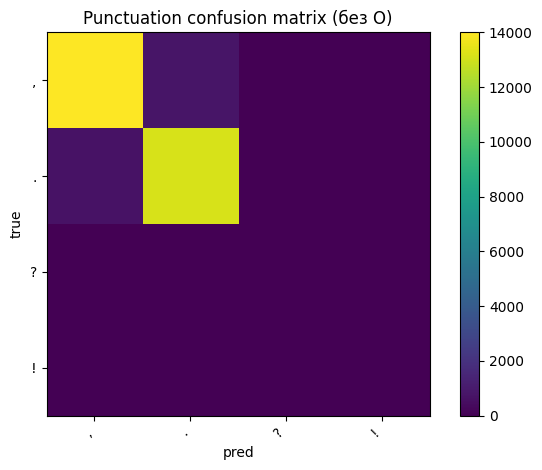

In [92]:
cm = confusion_matrix(punct_true_noO, punct_pred_noO, labels=labels_noO)

plt.figure()
plt.imshow(cm)
plt.title("Punctuation confusion matrix (без O)")
plt.xlabel("pred")
plt.ylabel("true")
plt.xticks(range(len(labels_noO)), target_names_noO, rotation=45, ha="right")
plt.yticks(range(len(labels_noO)), target_names_noO)
plt.colorbar()
plt.tight_layout()
plt.show()

In [94]:
bad_shown = 0
need_bad = 7

model.eval()

for sample in dataset["test"]:
    words = sample["words"]
    true_punct = sample["punct"]
    true_cap = sample["cap"]

    encoded = tokenizer(
        words,
        is_split_into_words=True,
        add_special_tokens=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    word_ids = encoded.word_ids(0)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(input_ids=encoded["input_ids"], attention_mask=encoded["attention_mask"])

    punct_token_preds = outputs["logits_punct"].argmax(-1)[0].tolist()
    cap_token_preds = outputs["logits_cap"].argmax(-1)[0].tolist()

    pred_punct = [punct2id["O"]] * len(words)
    pred_cap = [cap2id["O"]] * len(words)

    prev_word_id = None
    for token_i, word_id in enumerate(word_ids):
        if word_id is None:
            prev_word_id = None
            continue
        if word_id != prev_word_id:
            pred_punct[word_id] = punct_token_preds[token_i]
            pred_cap[word_id] = cap_token_preds[token_i]
        prev_word_id = word_id

    punct_errors = 0
    for i in range(len(words)):
        if true_punct[i] != o_id and pred_punct[i] != true_punct[i]:
            punct_errors += 1

    if punct_errors == 0:
        continue

    text_in = " ".join([w.lower() for w in words])

    out_words = []
    for i, w in enumerate(words):
        w = w.lower()
        cap_label = id2cap[pred_cap[i]]
        punct_label = id2punct[pred_punct[i]]

        if cap_label == "U":
            w = w[:1].upper() + w[1:]

        if punct_label != "O":
            w = w + punct_label

        out_words.append(w)
    text_out = " ".join(out_words)

    gold_words = []
    for i, w in enumerate(words):
        w = w.lower()
        cap_label = id2cap[true_cap[i]]
        punct_label = id2punct[true_punct[i]]

        if cap_label == "U":
            w = w[:1].upper() + w[1:]

        if punct_label != "O":
            w = w + punct_label

        gold_words.append(w)
    text_gold = " ".join(gold_words)

    print("IN  :", text_in)
    print("OUT :", text_out)
    print("GOLD:", text_gold)

    bad_shown += 1
    if bad_shown >= need_bad:
        break

IN  : the film opens in late 1950s los angeles at a quiet pot-luck wake for annie singer who has died and left husband manny ray liotta and daughter molly tina majorino we meet manny's mother eva erica yohn and father harry don ameche and the other characters as friends and family leave it is apparent that manny is in for difficulty molly will no longer speak due to her mother's passing and there is a need for a housekeeper nanny so that manny can return to a shaky job writing commercial jingles for his best friend and boss sid larry miller after one nanny washes out corrina washington whoopi goldberg interviews for the position she responds well to corrina and manny hires her very quickly a strong bond is formed between them corrina works out a system to talk with her without making her speak corrina sees the early struggles of life after annie's passing and molly slowly begins to interact more with corrina molly also begins to spend time with corrina's sister and family who take her 

### (honor, 10.0) 7. Сравнение нескольких претрейнов

Опционально: обучитесь (хотя бы 3-4 эпохи) на нескольких разных претрейнах и сравните качество.

Идеи:
- `bert-base-multilingual-cased`
- `distilbert-base-multilingual-cased`
- `DeepPavlov/rubert-base-cased`

Покажите таблицу: backbone → punct_F1_noO → cap_acc → cap_f1_upper → время/память (по желанию).


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 01 | train_loss=0.3651 | val_loss=0.2014 | punct_f1_micro_noO=0.8142 | punct_f1_macro_noO=0.4094 | cap_acc=0.9754 | cap_f1_upper=0.9394


Epoch 02 | train_loss=0.1736 | val_loss=0.1893 | punct_f1_micro_noO=0.8266 | punct_f1_macro_noO=0.4155 | cap_acc=0.9777 | cap_f1_upper=0.9450


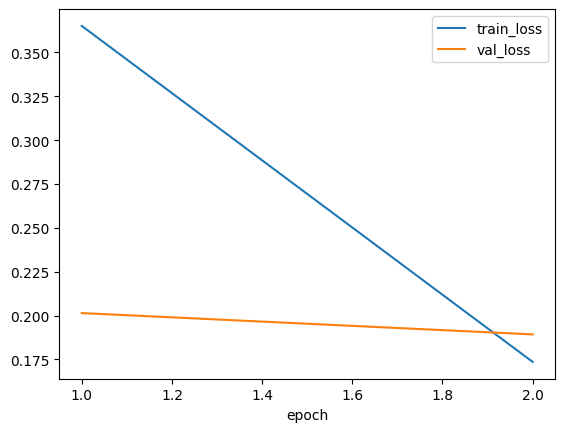

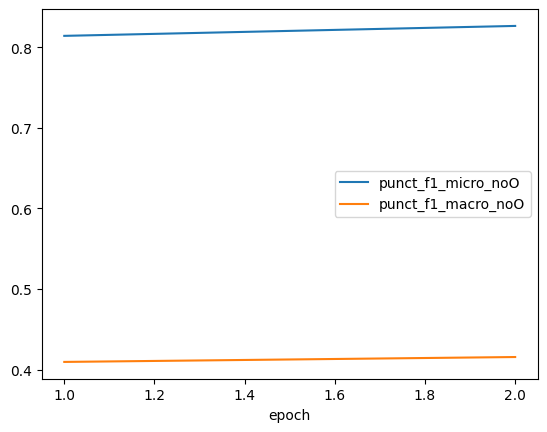

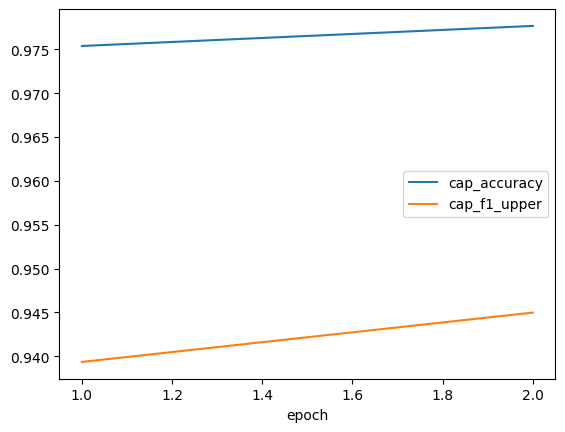

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Epoch 01 | train_loss=0.4357 | val_loss=0.2508 | punct_f1_micro_noO=0.6647 | punct_f1_macro_noO=0.3315 | cap_acc=0.9680 | cap_f1_upper=0.9190


Epoch 02 | train_loss=0.2243 | val_loss=0.2327 | punct_f1_micro_noO=0.7276 | punct_f1_macro_noO=0.3658 | cap_acc=0.9708 | cap_f1_upper=0.9275


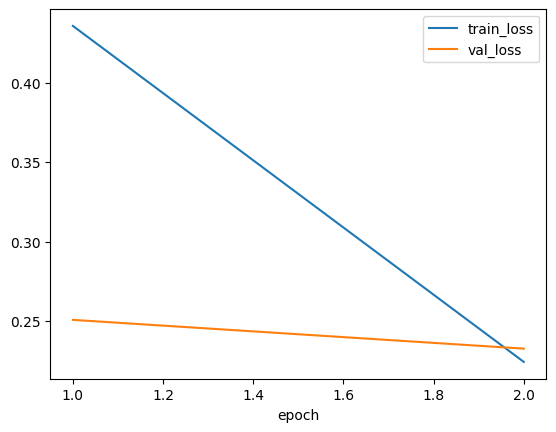

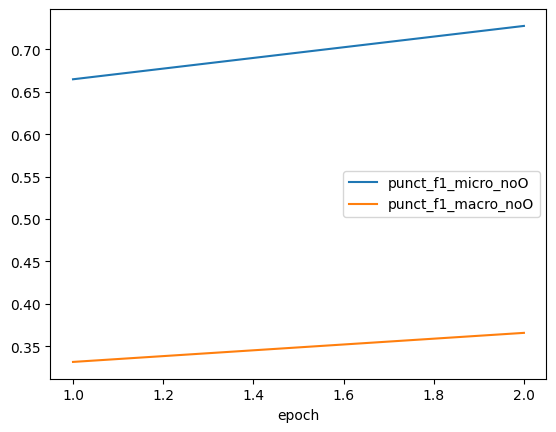

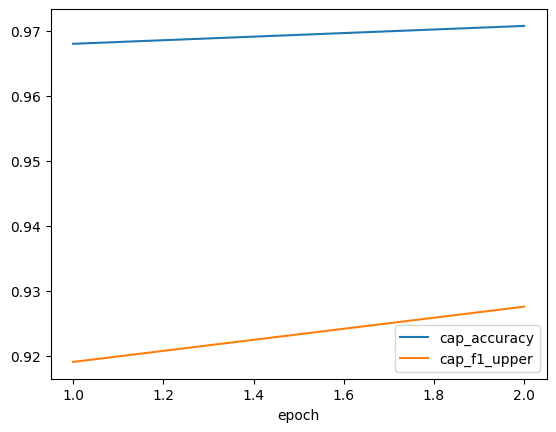

,backbone,punct_f1_micro_noO,punct_f1_macro_noO,cap_acc,cap_f1_upper,time_sec,gpu_peak_mem_mb
0,bert-base-multilingual-cased,0.826582,0.415522,0.977680,0.944981,294.654394,10791.734375
1,distilbert-base-multilingual-cased,0.727592,0.365764,0.970778,0.927525,168.716020,9517.493164


In [97]:
import time

def run_one_backbone(
    model_name,
    epochs = 2,
    batch_size = 16,
    lr = 5e-5,
    weight_decay = 0.01,
    max_length = 64,
    max_train_examples = 10000,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    train_split = dataset["train"]
    val_split   = dataset["val"]

    if max_train_examples is not None:
        train_split = train_split.select(range(min(max_train_examples, len(train_split))))

    train_ds = AlignedTokenDataset(train_split, tokenizer, max_length=max_length)
    val_ds   = AlignedTokenDataset(val_split,   tokenizer, max_length=max_length)

    collate_fn = Collator(tokenizer)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn, num_workers=8, pin_memory=True,
    persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True,
    persistent_workers=True)

    model = BertTwoHeads(model_name, num_punct=len(PUNCT_LABELS), num_cap=len(CAP_LABELS), dropout=0.1).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * 0.1)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    t0 = time.perf_counter()
    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        epochs=epochs
    )
    t1 = time.perf_counter()

    last = history[-1]

    peak_mem_mb = None
    if torch.cuda.is_available():
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024**2)

    return {
        "backbone": model_name,
        "punct_f1_micro_noO": last["punct_f1_micro_noO"],
        "punct_f1_macro_noO": last["punct_f1_macro_noO"],
        "cap_acc": last["cap_accuracy"],
        "cap_f1_upper": last["cap_f1_upper"],
        "time_sec": (t1 - t0),
        "gpu_peak_mem_mb": peak_mem_mb,
    }

backbones = [
    "bert-base-multilingual-cased",
    "distilbert-base-multilingual-cased"
]

results = []
for name in backbones:
    row = run_one_backbone(
        model_name=name,
        epochs=2,
        batch_size=16,
        lr=5e-5,
        weight_decay=0.01,
        max_length=128,
        max_train_examples=5000,
    )
    results.append(row)

df_res = pd.DataFrame(results)
df_res = df_res.sort_values(by=["punct_f1_micro_noO", "cap_f1_upper"], ascending=False)
display(df_res)


ВЫВОД: как мы видим, вторая модель хуже по качеству, но зато она гораздо быстрее и выгоднее по памяти.

Мне не хватило ресурсов и времени, поэтому я была вынуждена сильно сократить обучающую выборку и кол-во эпох((